# Multi-Constellation Mosaic Visualization — Buenos Aires

This notebook mosaics the **extracted data** from five satellite constellations (GOES, MODIS, VIIRS, Sentinel-2, Sentinel-3) over the **entire Buenos Aires province** and renders them side-by-side for a direct visual comparison.

> **WOW effect:** See the same geographic region through four different sensors, resolutions, and spectral bands — all aligned to a unified mosaic.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from aer.eoids import mosaic_eoids_tiles

## Configuration

Define the constellation directories and visual styling.

In [2]:
# --- Configuration ---
# Notebook is in visualization/; extracted data lives in examples/
BASE_DIR = Path("..").resolve()

CONSTELLATIONS = [
    {
        "label": "GOES-19 ABI",
        "dir": "extract_buenos_aires_goes",
        "cmap": "viridis",
        "band": "C07",
    },
    {
        "label": "MODIS Terra",
        "dir": "extract_buenos_aires_modis",
        "cmap": "plasma",
        "band": "31",
    },
    {
        "label": "VIIRS NOAA-21",
        "dir": "extract_buenos_aires_viirs",
        "cmap": "magma",
        "band": "I04",
    },
    {
        "label": "Sentinel-3 OLCI",
        "dir": "extract_buenos_aires_sentinel3",
        "cmap": "cividis",
        "band": "Oa04",
    },
]

TARGET_CRS = "EPSG:4326"

# Maximum pixel dimension for display — keeps memory low even for huge mosaics
MAX_DISPLAY_DIM = 2000

## Helper functions

Downsampling, masking, and percentile stretch — kept lightweight to avoid OOM.

In [3]:
def downsample_for_display(arr, max_dim=MAX_DISPLAY_DIM):
    """Strided downsample so the longest axis ≤ max_dim.
    Keeps memory tiny — no interpolation, just regular stride."""
    h, w = arr.shape[-2], arr.shape[-1]
    longest = max(h, w)
    if longest <= max_dim:
        return arr
    step = int(np.ceil(longest / max_dim))
    return arr[..., ::step, ::step]


def mask_invalid(data, is_viirs=False):
    """Mask NaN, zero-fill, and VIIRS uint16 sentinel as NaN (float32)."""
    data = data.astype(np.float32)
    invalid = np.isnan(data) | (data == 0)
    if is_viirs:
        invalid |= data == 65535
    data = np.where(invalid, np.nan, data)
    return data


def robust_vmin_vmax(data, lower=1, upper=99):
    """Compute percentile stretch excluding NaN."""
    valid = data[~np.isnan(data)]
    if len(valid) == 0:
        return 0, 1
    vmin, vmax = np.percentile(valid, [lower, upper])
    if vmin == vmax:
        vmin, vmax = valid.min(), valid.max()
    return float(vmin), float(vmax)


def load_mosaic(cfg):
    """Build mosaic, downsample, mask, and return display-ready data."""
    root = BASE_DIR / cfg["dir"]
    if not root.exists():
        return None

    mosaic, transform, crs = mosaic_eoids_tiles(
        root,
        target_crs=TARGET_CRS,
    )
    print(f"  -> raw shape {mosaic.shape}, CRS {crs}", flush=True)

    # Drop band dimension if present
    if mosaic.ndim == 3:
        band_data = mosaic[0]
    else:
        band_data = mosaic

    # Downsample *before* converting to float to save memory
    band_data = downsample_for_display(band_data, max_dim=MAX_DISPLAY_DIM)
    print(f"  -> display shape {band_data.shape}", flush=True)

    is_viirs = cfg["band"] == "I04"
    band_data = mask_invalid(band_data, is_viirs=is_viirs)
    vmin, vmax = robust_vmin_vmax(band_data)

    return band_data, vmin, vmax

## Build & render side-by-side mosaic comparison

Mosaics are built and downsampled **one at a time** so only one full-resolution array lives in memory.

Invalid values (nodata, zero-fill, and the VIIRS uint16 sentinel 65535) are masked so they do not distort the color scale.

Building mosaic for GOES-19 ABI ...
  -> raw shape (1, 442, 553), CRS EPSG:4326
  -> display shape (442, 553)
Building mosaic for MODIS Terra ...
  -> raw shape (1, 883, 1104), CRS EPSG:4326
  -> display shape (883, 1104)
Building mosaic for VIIRS NOAA-21 ...
  -> raw shape (1, 2336, 2922), CRS EPSG:4326
  -> display shape (1168, 1461)
Building mosaic for Sentinel-2 MSI ...
  -> raw shape (1, 9242, 11381), CRS EPSG:4326
  -> display shape (1541, 1897)
Building mosaic for Sentinel-3 OLCI ...
  -> raw shape (1, 2930, 3665), CRS EPSG:4326
  -> display shape (1465, 1833)


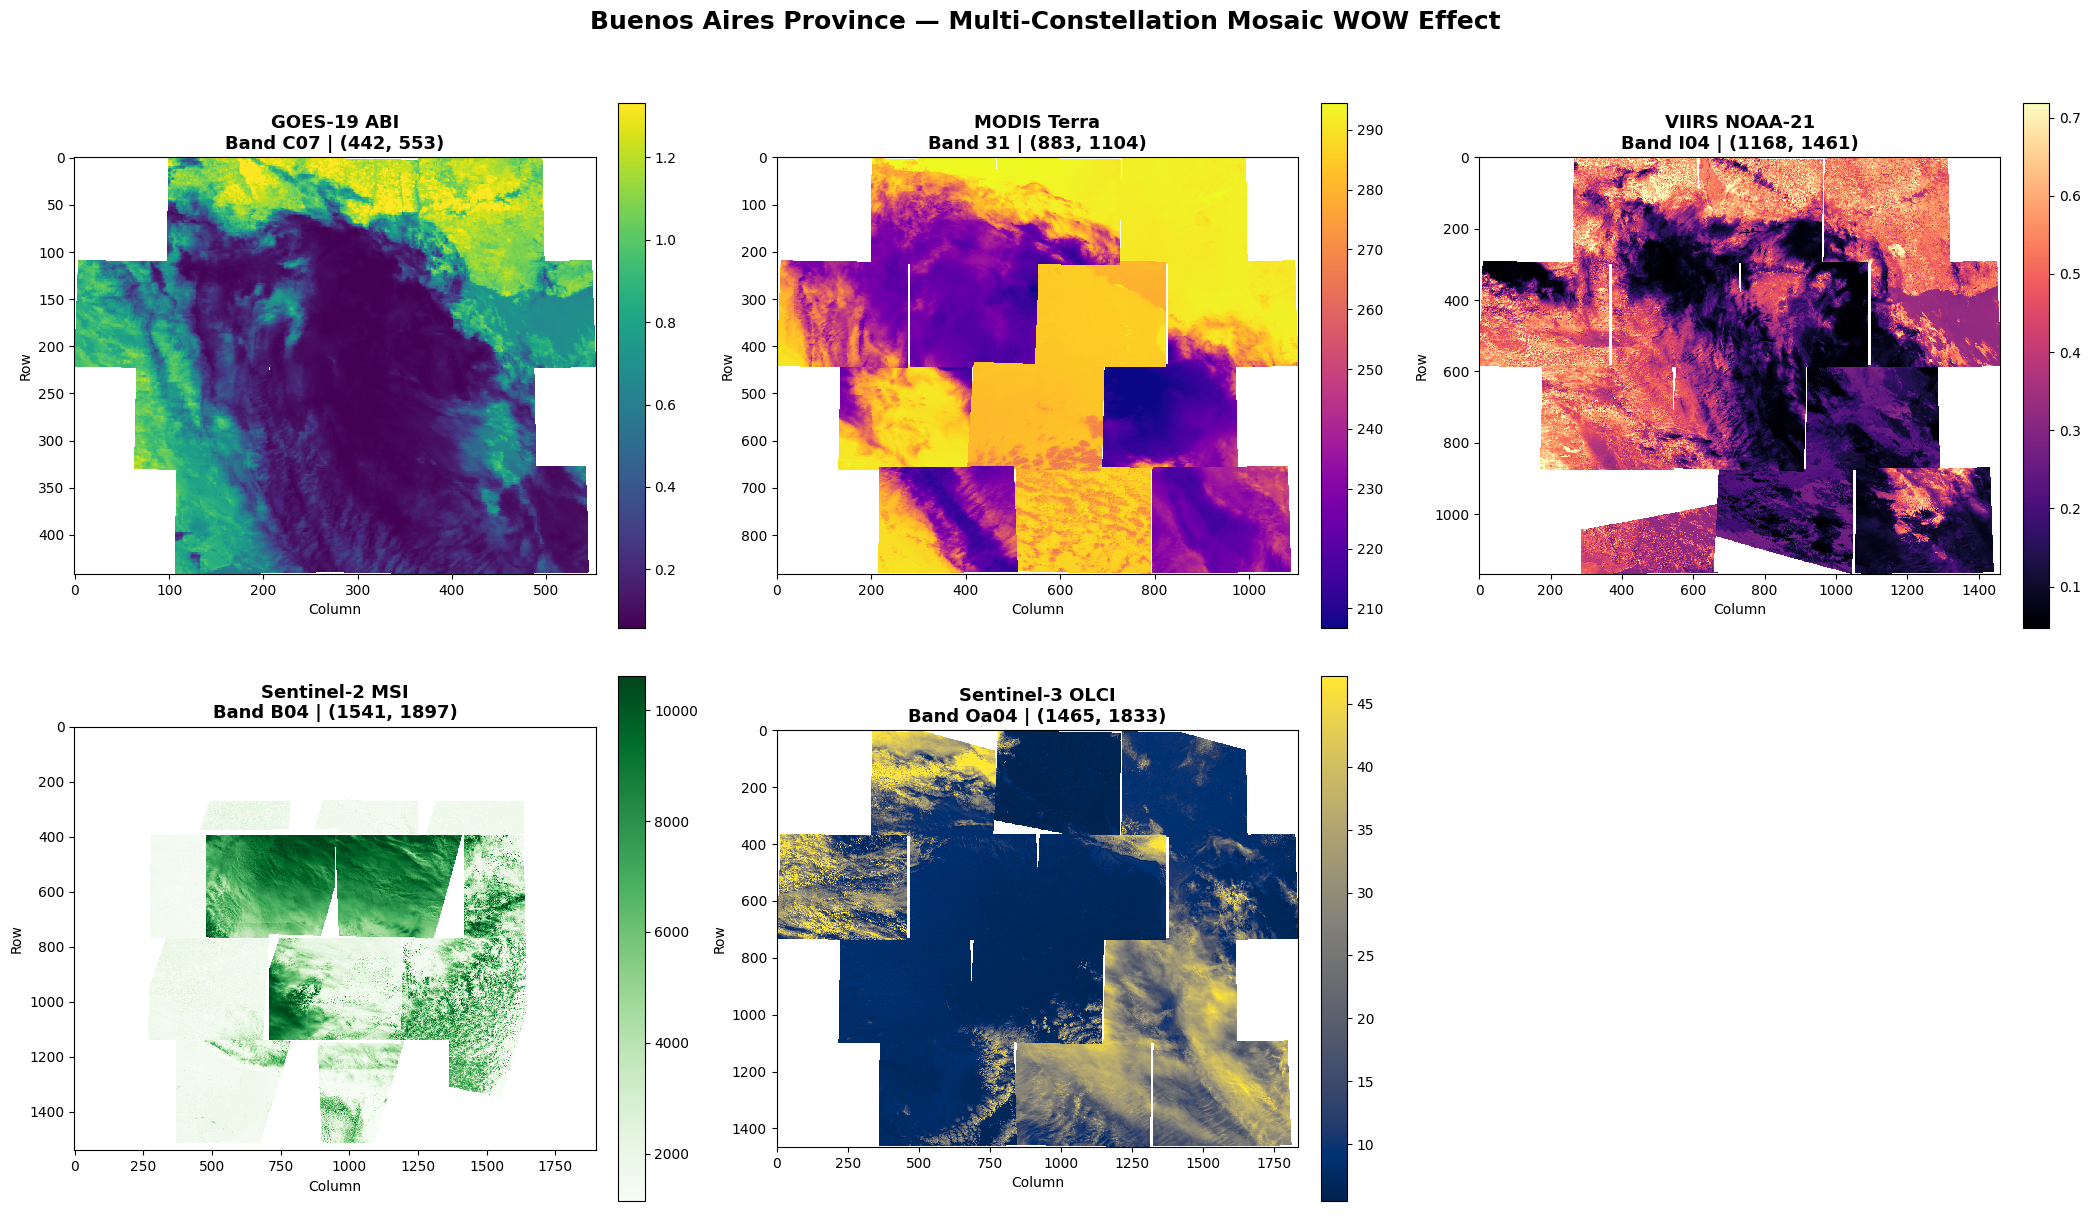

In [4]:
n = len(CONSTELLATIONS)
cols = 3 if n >= 5 else 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows), squeeze=False)
fig.suptitle(
    "Buenos Aires Province — Multi-Constellation Mosaic WOW Effect",
    fontsize=18,
    fontweight="bold",
    y=1.02,
)

for ax, cfg in zip(axes.flat, CONSTELLATIONS):
    print(f"Building mosaic for {cfg['label']} ...", flush=True)
    result = load_mosaic(cfg)
    if result is None:
        ax.set_title(f"{cfg['label']}\n(not found)")
        ax.axis("off")
        continue

    band_data, vmin, vmax = result

    im = ax.imshow(
        band_data,
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_title(
        f"{cfg['label']}\nBand {cfg['band']} | {band_data.shape}",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Hide any unused subplots
for ax in axes.flat[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## (Optional) Save the figure to disk

Uncomment the cell below to write the composite figure as a high-resolution PNG.

> **Note:** The saved PNG is rendered at figure DPI (default 100). The data has already been downsampled to `MAX_DISPLAY_DIM`, so increasing DPI simply enlarges pixels — it does not recover detail.

In [ ]:
fig.savefig("multi_constellation_mosaic.png", dpi=200, bbox_inches="tight")
print("Saved multi_constellation_mosaic.png")